# Расчет экономичекого ущерба

## Нормативно правовое обоснования методики расчета 

Федеральный закон "Об охране окружающей среды" от 10.01.2002 N 7-ФЗ 
Статья 77. Обязанность полного возмещения вреда окружающей среде
1. Юридические и физические лица, причинившие вред окружающей среде в результате ее загрязнения, истощения, порчи, уничтожения, нерационального использования природных ресурсов, деградации и разрушения естественных экологических систем, природных комплексов и природных ландшафтов и иного нарушения законодательства в области охраны окружающей среды, обязаны возместить его в полном объеме в соответствии с законодательством.

3. Вред окружающей среде, причиненный юридическим лицом или индивидуальным предпринимателем, возмещается в соответствии с утвержденными в установленном порядке таксами и методиками исчисления размера вреда окружающей среде, а при их отсутствии исходя из фактических затрат на восстановление нарушенного состояния окружающей среды, с учетом понесенных убытков, в том числе упущенной выгоды.
(в ред. Федерального закона от 21.07.2014 N 219-ФЗ)


Постановление Правительства РФ от 03.11.2018 N 1321 (ред. от 08.09.2023) "Об утверждении такс для исчисления размера ущерба, причиненного водным биологическим ресурсам"




## Предварительный анализ данных

Подключаем библиотеки 

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

Открываем файл и читаем

In [11]:
file_path = "kiyazevo_iot_realistic.csv"
df = pd.read_csv(file_path, parse_dates=['timestamp'])
print(df.head())

            timestamp  ec_microsiemens  temperature_celsius sensor_id  \
0 2026-04-01 00:00:00           4421.2                  8.8  YAIVA_01   
1 2026-04-01 01:00:00           4551.9                  7.9  YAIVA_01   
2 2026-04-01 02:00:00           4396.0                  6.6  YAIVA_01   
3 2026-04-01 03:00:00           3749.4                  5.4  YAIVA_01   
4 2026-04-01 04:00:00           3462.5                  4.3  YAIVA_01   

                                location  
0  Яйва, 500 м ниже штольни им. Калинина  
1  Яйва, 500 м ниже штольни им. Калинина  
2  Яйва, 500 м ниже штольни им. Калинина  
3  Яйва, 500 м ниже штольни им. Калинина  
4  Яйва, 500 м ниже штольни им. Калинина  


Строим граффики

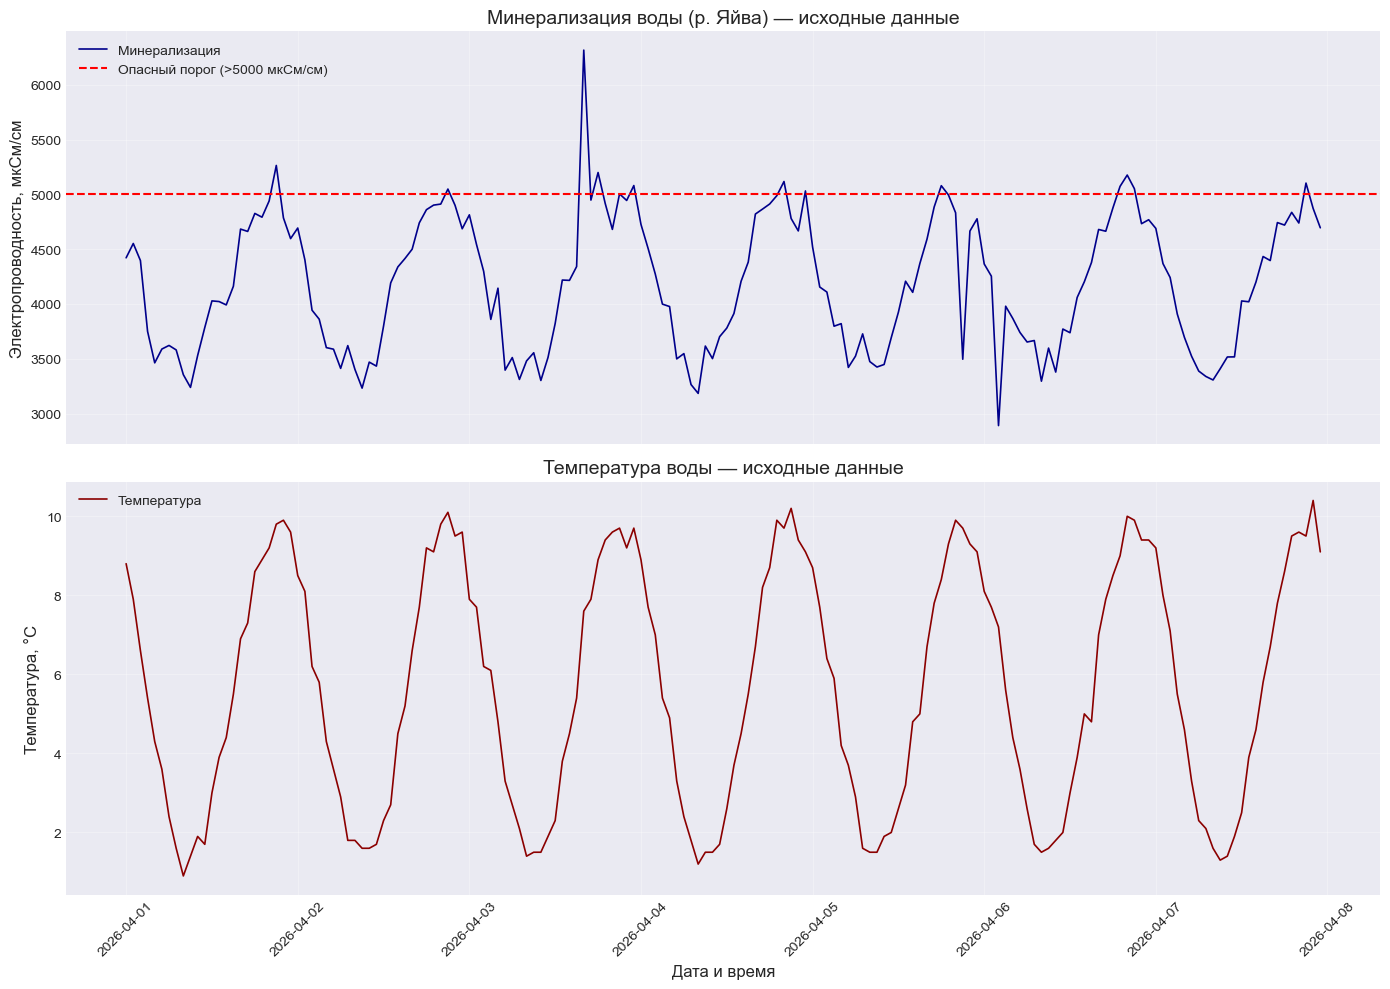

In [12]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df['timestamp'], df['ec_microsiemens'], 
             color='darkblue', linewidth=1.2, label='Минерализация')
axes[0].axhline(y=5000, color='red', linestyle='--', linewidth=1.5, 
                label='Опасный порог (>5000 мкСм/см)')
axes[0].set_ylabel('Электропроводность, мкСм/см', fontsize=12)
axes[0].set_title('Минерализация воды (р. Яйва) — исходные данные', fontsize=14)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['timestamp'], df['temperature_celsius'], 
             color='darkred', linewidth=1.2, label='Температура')
axes[1].set_ylabel('Температура, °C', fontsize=12)
axes[1].set_xlabel('Дата и время', fontsize=12)
axes[1].set_title('Температура воды — исходные данные', fontsize=14)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()